#### The goal is to answer:

Which model predicts churn best?

### 1: Import Libraries

In [1]:
# Load necessary libraries
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### 2: Load Processed Data

In [2]:
# Load the processed data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
# Check 

print(X_train.shape)
print(X_test.shape)

(5625, 31)
(1407, 31)


### 3: Logistic Regression

In [4]:
# Train
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [5]:
# Predict
y_pred_lr = lr.predict(X_test)

In [6]:
# Evaluate the model
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_lr))

Accuracy : 0.8073916133617626
Precision: 0.6467236467236467
Recall   : 0.606951871657754
F1 Score : 0.6262068965517241
ROC AUC  : 0.7434565747446563


In [7]:
# Classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.65      0.61      0.63       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.75      1407
weighted avg       0.80      0.81      0.81      1407



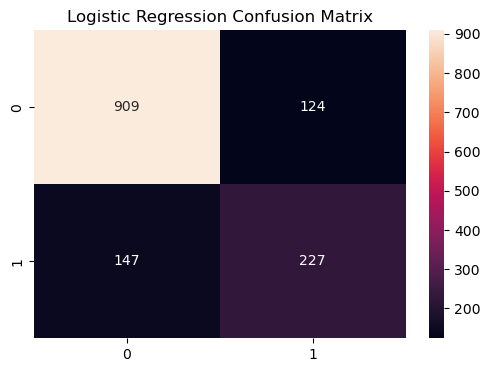

In [8]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")

plt.savefig(
    "../images/logistic_regression_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### 4: Decision Tree

In [9]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [10]:
# Evaluate the model
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_dt))

Accuracy : 0.7434257285003554
Precision: 0.5172413793103449
Recall   : 0.5213903743315508
F1 Score : 0.5193075898801598
ROC AUC  : 0.672602253961516


              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1033
           1       0.52      0.52      0.52       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407



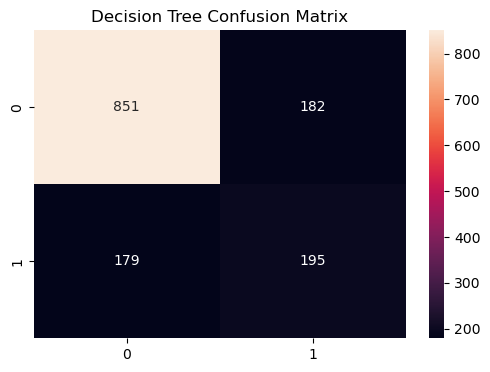

In [15]:
# Classification report and confusion matrix
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")

plt.savefig(
    "../images/decision_tree_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### 5: Random Forest

In [11]:
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Evaluate the model
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



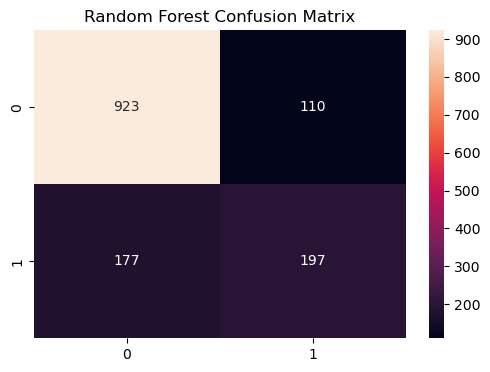

In [16]:
# Classification report and confusion matrix
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "../images/random_forest_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### 6: Model Comparison Table

In [12]:
# Create a DataFrame to compare the models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.807392,0.646724,0.606952,0.626207
1,Decision Tree,0.743426,0.517241,0.521390,0.519308
2,Random Forest,0.796020,0.641694,0.526738,0.578561


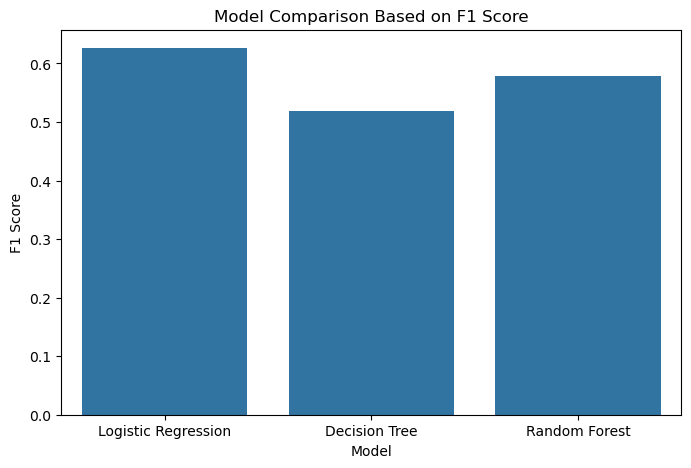

In [ ]:
# Model Comparision Plot
# Visualize the model comparison based on F1 Score
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison Based on F1 Score")

plt.savefig(
    "../images/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

### 7: Feature Importance

In [13]:
# Visualize the top 10 important features
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Total Charges,0.161974
0,Tenure Months,0.149822
1,Monthly Charges,0.134739
3,CLTV,0.124363
11,Internet Service_Fiber optic,0.039600
7,Dependents_Yes,0.038220
29,Payment Method_Electronic check,0.032438
26,Contract_Two year,0.029437
4,Gender_Male,0.022274
14,Online Security_Yes,0.021369


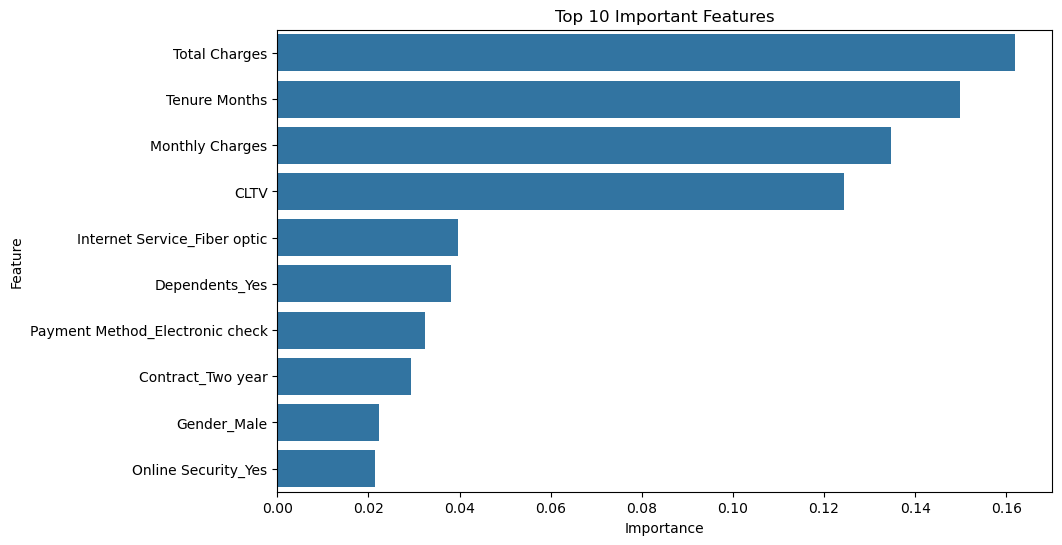

In [ ]:
# Visualize the top 10 important features
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig(
    "../images/top_10_feature_importance.png",
    bbox_inches="tight"
)

plt.show()


### 8: Save the Model

In [17]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(
    lr,
    "../models/customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [18]:
# Verfication of the saved model
import joblib

loaded_model = joblib.load(
    "../models/customer_churn_model.pkl"
)

print(loaded_model)

LogisticRegression(max_iter=1000, random_state=42)
